In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

Using device: cpu


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Use first 500 images as in the manual
dataset = Subset(dataset, range(500))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)


In [5]:
def train_and_evaluate(model, name, num_epochs=5):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):

        model.train()

        correct = 0
        total = 0

        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            # GoogLeNet may return auxiliary outputs
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_accuracy = 100 * correct / total
        train_accs.append(train_accuracy)


        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                _, predicted = torch.max(outputs, 1)

                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_accuracy = 100 * correct / total
        val_accs.append(val_accuracy)

        print(
            f"{name} Epoch {epoch + 1}/{num_epochs} - "
            f"Train Acc: {train_accuracy:.2f}%, "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    return model, train_accs, val_accs

In [6]:
def get_model(name):
    name = name.lower().strip()

    if name == "vgg":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(4096, 10)

    elif name == "resnet":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 10)

    elif name == "googlenet":
        model = models.googlenet(
            weights=models.GoogLeNet_Weights.DEFAULT,
            aux_logits=True
        )
        model.fc = nn.Linear(model.fc.in_features, 10)

    else:
        raise ValueError(
            f"Unknown model: '{name}'. "
            "Choose from: vgg, resnet, googlenet"
        )

    return model

In [7]:
results = {}
trained_models = {}

for model_name in ["vgg", "resnet", "googlenet"]:

    print(
        f"\nTraining {model_name.upper()} on CIFAR-10..."
    )

    model = get_model(model_name)

    trained_model, train_acc, val_acc = train_and_evaluate(
        model,
        model_name.upper(),
        num_epochs=5
    )

    results[model_name] = (
        train_acc,
        val_acc
    )

    trained_models[model_name] = trained_model



Training VGG on CIFAR-10...
VGG Epoch 1/5 - Train Acc: 20.50%, Val Acc: 56.00%
VGG Epoch 2/5 - Train Acc: 54.75%, Val Acc: 62.00%
VGG Epoch 3/5 - Train Acc: 74.75%, Val Acc: 68.00%
VGG Epoch 4/5 - Train Acc: 84.75%, Val Acc: 66.00%
VGG Epoch 5/5 - Train Acc: 90.00%, Val Acc: 72.00%

Training RESNET on CIFAR-10...
RESNET Epoch 1/5 - Train Acc: 24.75%, Val Acc: 44.00%
RESNET Epoch 2/5 - Train Acc: 89.75%, Val Acc: 60.00%
RESNET Epoch 3/5 - Train Acc: 97.75%, Val Acc: 64.00%
RESNET Epoch 4/5 - Train Acc: 99.25%, Val Acc: 69.00%
RESNET Epoch 5/5 - Train Acc: 100.00%, Val Acc: 72.00%

Training GOOGLENET on CIFAR-10...


C:\Users\Zaara\anaconda3\Lib\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


GOOGLENET Epoch 1/5 - Train Acc: 17.00%, Val Acc: 29.00%
GOOGLENET Epoch 2/5 - Train Acc: 64.50%, Val Acc: 49.00%
GOOGLENET Epoch 3/5 - Train Acc: 83.00%, Val Acc: 62.00%
GOOGLENET Epoch 4/5 - Train Acc: 90.75%, Val Acc: 66.00%
GOOGLENET Epoch 5/5 - Train Acc: 95.25%, Val Acc: 69.00%


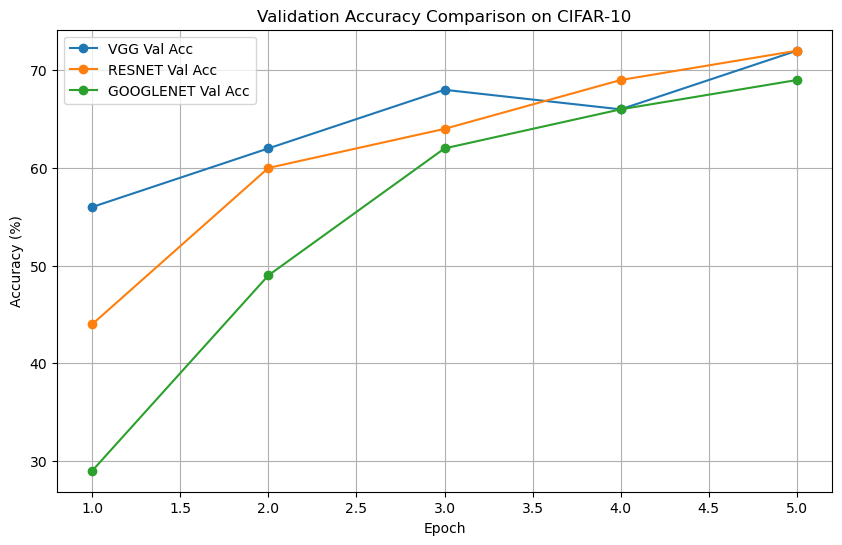

In [8]:
plt.figure(figsize=(10, 6))

for name, (train_acc, val_acc) in results.items():

    plt.plot(
        range(1, len(val_acc) + 1),
        val_acc,
        marker='o',
        label=f'{name.upper()} Val Acc'
    )

plt.title(
    'Validation Accuracy Comparison on CIFAR-10'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.legend()
plt.grid(True)

plt.show()


In [9]:
def predict_image(image_path, models_dict):

    image = Image.open(
        image_path
    ).convert('RGB')

    image = transform(image)

    image = image.unsqueeze(0)

    image = image.to(device)

    print(
        f"\nPrediction results for image: {image_path}"
    )

    for model_name, model in models_dict.items():

        model.eval()

        with torch.no_grad():

            outputs = model(image)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = outputs.max(1)

            pred_class = class_names[
                predicted.item()
            ]

        print(
            f"{model_name.upper():<10} => {pred_class}"
        )


In [11]:
custom_image_path = r"C:\Users\Zaara\Downloads\images.jpg"

if os.path.exists(custom_image_path):

    predict_image(
        custom_image_path,
        trained_models
    )

else:

    print(f"\nImage not found: {custom_image_path}")


Prediction results for image: C:\Users\Zaara\Downloads\images.jpg
VGG        => dog
RESNET     => dog
GOOGLENET  => automobile
